# Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])
df

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
...,...,...,...,...,...,...,...,...,...
600,M0072,2026-01-07 23:00:00,C012,B004,23.67,60.28,1015.11,282.36,OK
601,M0107,2026-01-09 10:00:00,C011,B004,24.34,61.42,1019.43,357.43,OK
602,M0271,2026-01-16 06:00:00,C007,B003,23.73,63.49,1016.46,152.79,OK
603,M0436,2026-01-23 03:00:00,C004,B002,24.83,79.77,1017.05,170.97,OK


# Partie 1 – Distribution d'une variable avec histplot()

## 1) Afficher la distribution des températures

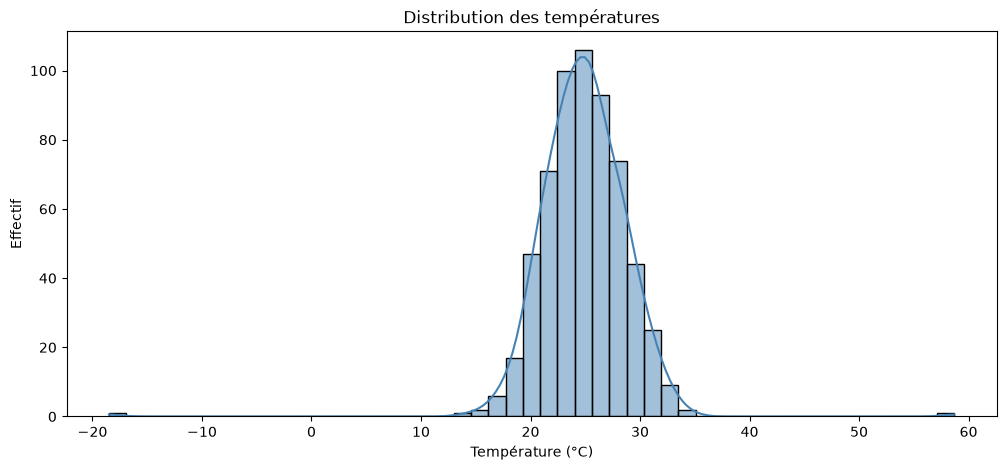

In [20]:
plt.subplots(figsize=(12,5))
sns.histplot(df, x="temperature", color="steelblue", kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Effectif")
plt.show()

## 2) Autour de quelle valeur les températures sont concentrées ?

In [19]:
print("Moyenne :", df["temperature"].mean().round(2))
print("Médiane :", df["temperature"].median().round(2))

Moyenne : 24.88
Médiane : 24.86


les temperatures sont concentrees au tour de la moyenne 24, 88

## 3) La distribution semble-t-elle symétrique ?

Oui, Car la moyenne et sensiblement egale a la mediane

## 4) Existe-t-il des valeurs extrêmes ?

In [21]:
q1, q3 = df["temperature"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["temperature"] < lower) | (df["temperature"] > upper)]
print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
print(f"Nombre de valeurs extrêmes : {len(outliers)}")
outliers[["id_mesure", "batiment", "temperature"]]

Bornes IQR : [15.51, 34.33]
Nombre de valeurs extrêmes : 5


,id_mesure,batiment,temperature
43,M0575,B004,34.72
245,M0127,B003,14.11
258,M0223,B003,15.49
487,M0538,B004,-18.50
502,M0048,B004,58.70


Oui, on a 5 valeurs aberant

## 5) Modifier le nombre de classes

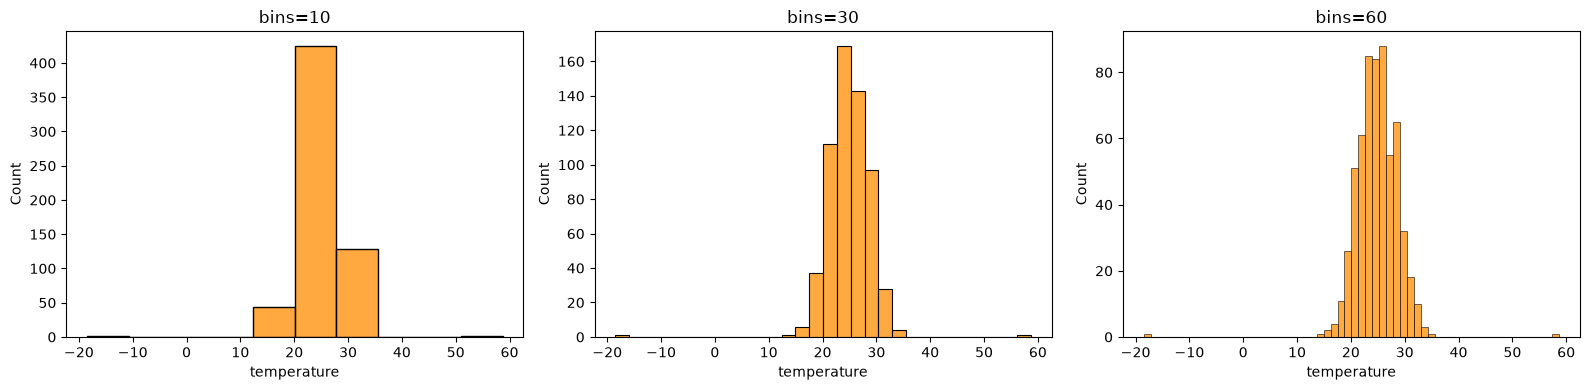

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=b, ax=ax, color="darkorange")
    ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

## 6) Afficher la distribution des températures par bâtiment

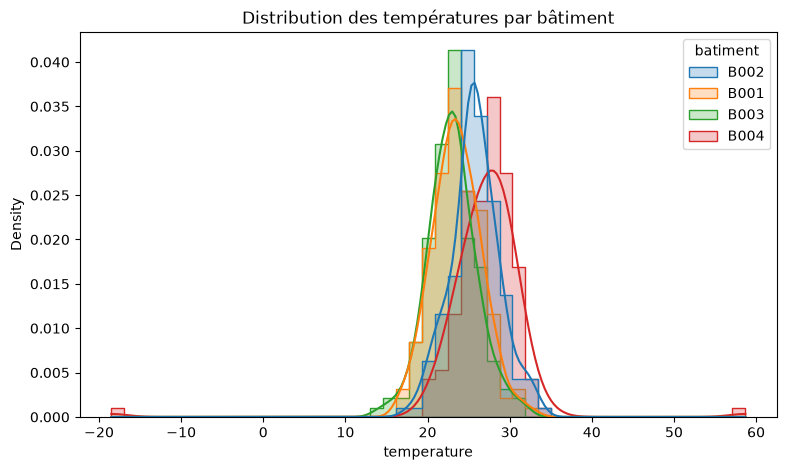

In [30]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step", stat="density")
plt.title("Distribution des températures par bâtiment")
plt.show()